# Домашнє завдання до модуля «Підходи до покращення якості»
## Функції
### Функція показу подвіної репрезентації важливості ознак

In [98]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def draw_grouped_barplot(df: pd.DataFrame, x_value, y_value, hue_value):
    # Перетворюємо DataFrame у довгий формат
    # df містить рядки з score_type та колонки з назвами ознак
    df_melted = df.melt(
        id_vars=hue_value,
        var_name=y_value,
        value_name=x_value
    )

    sns.set_theme(style="whitegrid")
    g = sns.catplot(
        data=df_melted,
        kind="bar",
        x=x_value,      # значення на осі X
        y=y_value,      # features на осі Y
        hue=hue_value,  # групування за типом Score
        height=8,
        aspect=1.2,
        palette="Set2",
        legend=True,
        legend_out=False,
        orient='h'      # горизонтальна орієнтація
    )

    g.despine(left=True)
    g.set_axis_labels("value", "")

    # Налаштування легенди
    plt.legend(title="Парне представлення", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

### Завантаження датасетів


In [37]:
import pickle
import requests
import logging
from typing import Any

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

DATA_URL: str = "https://raw.githubusercontent.com/goitacademy/MACHINE-LEARNING-NEO/refs/heads/main/datasets/mod_05_topic_10_various_data.pkl"


def get_desired_datasets(timeout: float = 15.0) -> Any:
    """
    Завантажує та розпаковує pickle з віддаленого джерела.

    :param timeout: таймаут HTTP-запиту в секундах.
    :return: десеріалізовані дані.
    :raises: requests.RequestException, pickle.UnpicklingError, та інші винятки.
    """
    try:
        response = requests.get(DATA_URL, timeout=timeout)
        response.raise_for_status()
        content: bytes = response.content
        return pickle.loads(content)
    except requests.RequestException as http_err:
        logging.error("Помилка HTTP під час завантаження з %s: %s", DATA_URL, http_err)
        raise
    except pickle.UnpicklingError as unpickle_err:
        logging.error("Помилка десеріалізації pickle з %s: %s", DATA_URL, unpickle_err)
        raise
    except Exception as err:
        logging.error("Несподівана помилка під час обробки даних з %s: %s", DATA_URL, err)
        raise

## Завантажуємо дані

In [38]:
datasets = get_desired_datasets()
autos = datasets['autos']

autos.head()

,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9,111,5000,21,27,13495
1,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9,111,5000,21,27,16500
2,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9,154,5000,19,26,16500
3,audi,gas,std,4,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10,102,5500,24,30,13950
4,audi,gas,std,4,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8,115,5500,18,22,17450


## Генеруємо нову ознаку
Генеруємо ознаку *stroke_ratio* на основі ознак *stroke* і *bore*. Вона надає додаткову корисну інформацію моделі щодо прогнозування.

In [39]:
autos['stroke_ratio'] = autos['stroke'] / autos['bore']
autos[['stroke', 'bore', 'stroke_ratio']].head()

,stroke,bore,stroke_ratio
0,2.68,3.47,0.772334
1,2.68,3.47,0.772334
2,3.47,2.68,1.294776
3,3.40,3.19,1.065831
4,3.40,3.19,1.065831


## Створюємо конвеєр обробки даних
Розбиваємо даних на самі дані та ціьову змінну. Самі дані обробляємо наступним чином:
- Кодуємо категоріальні дані через **TargetEncoder**, який найкраще співпрацює з дискретними ознаками та дозволяє вивести з ними кореляцію
- Числові дані окрім дискретних заповнюємо значення, котрих бракує через **SimpleImputer**, а стандартизуємо через **StandardScaler**
- Збираємо валідаційний датасет з передоброблених частин

In [40]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline

X = autos.drop(columns=["price"])
y = autos["price"]

discrete_cols = ["num_of_doors", "num_of_cylinders", "engine_size", "city_mpg", "highway_mpg"]

# 1) Отримати фактично числові колонки
numeric_dtypes_cols = X.select_dtypes(include=["number"]).columns.tolist()

# 2) Вилучити лише ті дискретні, які реально є серед numeric_dtypes_cols
numeric_cols = [c for c in numeric_dtypes_cols if c not in discrete_cols]

# 3) Категоріальні — все, що не numeric
categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

cat_encoder = Pipeline(steps=[
    ("target_encoder", TargetEncoder(smoothing=5))
])

num_preprocessor = Pipeline(steps=[
    ("standard_scaler", StandardScaler()),
    ('simple_imputer', SimpleImputer(strategy='median'))
])

prep = ColumnTransformer(transformers=[
    ("num", num_preprocessor, numeric_cols),
    ("cat", cat_encoder, categorical_cols)
], remainder="drop", verbose_feature_names_out=False)

# Створюємо повний пайплайн (за потреби)
full_pipe = Pipeline(steps=[
    ("prep", prep)
])

X_trans = full_pipe.fit_transform(X, y)

ohe = full_pipe.named_steps["prep"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(categorical_cols))
feature_names = numeric_cols + cat_feature_names

X_trans = pd.DataFrame(X_trans, columns=feature_names, index=getattr(X, "index", None))

X_trans.head()

,wheel_base,length,width,height,curb_weight,bore,stroke,compression_ratio,horsepower,peak_rpm,stroke_ratio,make,fuel_type,aspiration,body_style,drive_wheels,engine_location,engine_type,fuel_system
0,-1.682379,-0.444024,-0.841263,-2.122598,-0.025713,0.513027,-1.808186,-0.215472,0.198569,-0.213359,-1.680738,13356.505699,12977.252874,12578.449367,13778.327617,20136.942495,12949.610526,14096.610729,17912.266987
1,-1.682379,-0.444024,-0.841263,-2.122598,-0.025713,0.513027,-1.808186,-0.215472,0.198569,-0.213359,-1.680738,13356.505699,12977.252874,12578.449367,13778.327617,20136.942495,12949.610526,14096.610729,17912.266987
2,-0.720911,-0.251195,-0.184679,-0.615412,0.497764,-2.394827,0.702918,-0.215472,1.334283,-0.213359,2.499096,13356.505699,12977.252874,12578.449367,9764.632252,20136.942495,12949.610526,15621.898590,17912.266987
3,0.142781,0.182672,0.143612,0.180047,-0.427362,-0.517605,0.480415,0.035047,-0.039139,0.856208,0.667402,13547.234756,12977.252874,12578.449367,14563.738418,9231.061431,12949.610526,11622.156028,17912.266987
4,0.077596,0.182672,0.237410,0.180047,0.499668,-0.517605,0.480415,-0.465991,0.304217,0.856208,0.667402,13547.234756,12977.252874,12578.449367,14563.738418,13031.846064,12949.610526,11622.156028,17912.266987


## Створюємо та виводимо набір ознак з їх важливістю згідно **Mutual Info Regression**

In [41]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X_trans, y, discrete_features=False, random_state=None)

mi_series = pd.Series(mi, index=X_trans.columns).sort_values(ascending=False)

mi_series

curb_weight          0.917887
horsepower           0.881199
width                0.691902
wheel_base           0.595699
length               0.594666
bore                 0.487802
make                 0.459493
fuel_system          0.450825
stroke_ratio         0.404077
stroke               0.379147
height               0.360443
drive_wheels         0.330519
peak_rpm             0.207406
engine_type          0.144970
compression_ratio    0.099757
aspiration           0.087755
body_style           0.078686
fuel_type            0.047298
engine_location      0.000000
dtype: float64

## Для практичної перевірки робимо відбір важливих ознак за допомогою **SelectKBest**

In [42]:
from sklearn.feature_selection import SelectKBest
selector = SelectKBest(mutual_info_regression, k=5)
X_new = selector.fit_transform(X_trans, y)
X_new = pd.DataFrame(X_new, columns=X_trans.columns[selector.get_support()])
X_new.head()

,wheel_base,length,width,curb_weight,horsepower
0,-1.682379,-0.444024,-0.841263,-0.025713,0.198569
1,-1.682379,-0.444024,-0.841263,-0.025713,0.198569
2,-0.720911,-0.251195,-0.184679,0.497764,1.334283
3,0.142781,0.182672,0.143612,-0.427362,-0.039139
4,0.077596,0.182672,0.237410,0.499668,0.304217


З виводу бачимо, що вибір та оцінювання ознак збігається з **Mutual Info Regression**.

## Створюємо модель на основі ансамблю **GradientBoostingRegressor** та робимо прогноз
Застосовуємо модель та оцінюємо за допомогою:
- **RMSE**
- **MAPE**

In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_trans, y, test_size=0.2, random_state=42)

# Модель
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

# Навчання
gbr.fit(X_train, y_train)

# Прогнозування
y_pred = gbr.predict(X_test)

# Оцінка
rmse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"RMSE: {rmse:.3f}")
print(f'Validation MAPE: {mape:.2%}')

RMSE: 7183008.065
Validation MAPE: 10.38%


## Повторюємо попередній крок, попередньо перетворивши вхідний датасет методом **.rank(pct=True)**

In [44]:
X_trans_1 = X_trans.rank(pct=True)

X_train, X_test, y_train, y_test = train_test_split(X_trans_1, y, test_size=0.2, random_state=42)

# Модель
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

# Навчання
gbr.fit(X_train, y_train)

# Прогнозування
y_pred = gbr.predict(X_test)

# Оцінка
rmse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"RMSE: {rmse:.3f}")
print(f'Validation MAPE: {mape:.2%}')

RMSE: 7257754.847
Validation MAPE: 10.40%


Як бачимо, що дане перетворення дещо понижує якість моделі.

## Отримуємо метрики важливості ознак згадно з створеної нами моделі

In [45]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(gbr.feature_importances_, index=X_train.columns).sort_values(ascending=False)

feat_imp

curb_weight          0.524112
make                 0.356840
horsepower           0.047167
width                0.020323
engine_type          0.018711
wheel_base           0.006388
fuel_system          0.005233
length               0.005031
height               0.004044
peak_rpm             0.003478
bore                 0.002550
body_style           0.001799
drive_wheels         0.001451
stroke_ratio         0.000852
stroke               0.000798
compression_ratio    0.000691
aspiration           0.000513
engine_location      0.000011
fuel_type            0.000008
dtype: float64

## Виводимо порівняльний графік важливості ознак згідно з **Mutual Info Regression** та згенеровані нашою моделлю

In [84]:
# Створюємо DataFrame з правильною структурою
score_types = ["MI Score", "GB Score"]
all_features = pd.DataFrame([mi_series, feat_imp], index=score_types)
all_features["score_type"] = all_features.index
all_features

,curb_weight,horsepower,width,wheel_base,length,bore,make,fuel_system,stroke_ratio,stroke,height,drive_wheels,peak_rpm,engine_type,compression_ratio,aspiration,body_style,fuel_type,engine_location,score_type
MI Score,0.917887,0.881199,0.691902,0.595699,0.594666,0.487802,0.459493,0.450825,0.404077,0.379147,0.360443,0.330519,0.207406,0.144970,0.099757,0.087755,0.078686,0.047298,0.000000,MI Score
GB Score,0.524112,0.047167,0.020323,0.006388,0.005031,0.002550,0.356840,0.005233,0.000852,0.000798,0.004044,0.001451,0.003478,0.018711,0.000691,0.000513,0.001799,0.000008,0.000011,GB Score


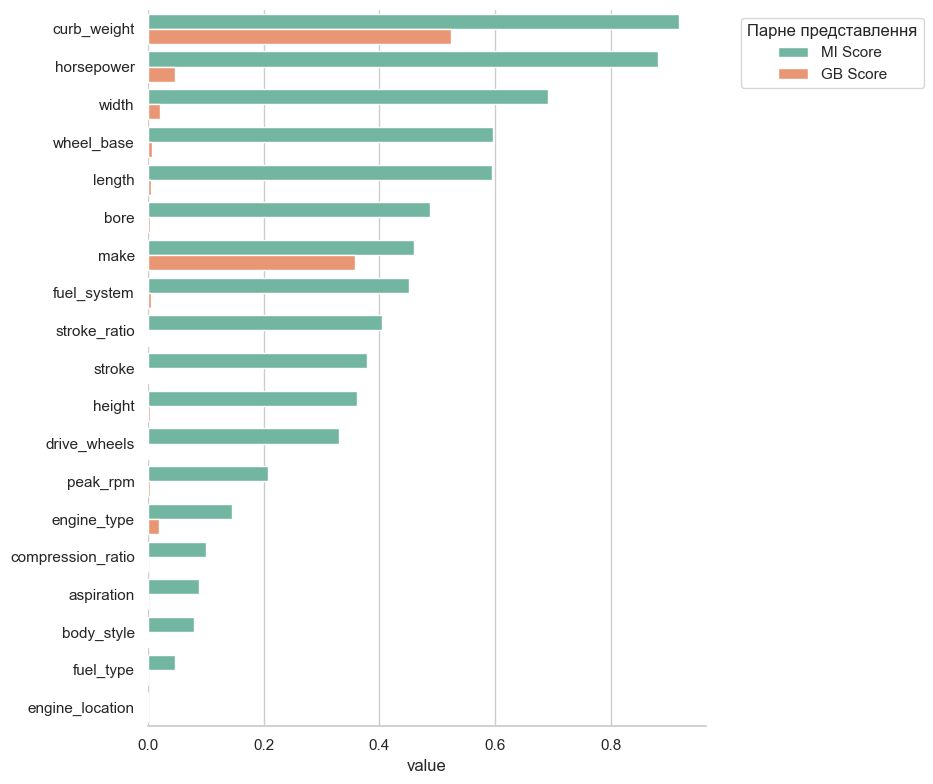

In [99]:
draw_grouped_barplot(all_features, hue_value='score_type', x_value="value", y_value="variable")

## Висновки
Цікаво те, що модель на основі ансамблю **GradientBoostingRegressor** явно оптимізованіше обирає ознаки, на основі яких навчається. Бачимо, що модель реально важливими вважає 8 ознак, в той час, як **Mutual Info Regression** вважає важливими 20 ознак. Обидва найважливішою вважають ознаку **curb_weight**, натомість другою за важливістю наша модель вважає виробника, тоді коли регресор вважає кінські сили. Зрештою, обидва мають сенс.